# LAB 06: NHẬN DIỆN ẢNH (IMAGE DETECTION)

In [1]:
# Cài đặt thư viện
!pip install opencv-python -q

In [10]:
import cv2
import os

# Dùng XML có sẵn trong opencv-python, không cần tải
CASCADE_DIR = cv2.data.haarcascades
print('Thư mục Haar Cascades:', CASCADE_DIR)

FACE_XML  = CASCADE_DIR + 'haarcascade_frontalface_default.xml'
EYE_XML   = CASCADE_DIR + 'haarcascade_eye.xml'
SMILE_XML = CASCADE_DIR + 'haarcascade_smile.xml'
NOSE_XML  = CASCADE_DIR + 'haarcascade_mcs_nose.xml'    if os.path.exists(CASCADE_DIR + 'haarcascade_mcs_nose.xml')    else CASCADE_DIR + 'haarcascade_frontalface_alt2.xml'
MOUTH_XML   = CASCADE_DIR + 'haarcascade_mcs_mouth.xml' if os.path.exists(CASCADE_DIR + 'haarcascade_mcs_mouth.xml') else CASCADE_DIR + 'haarcascade_profileface.xml'

print('\nCác file XML sẽ dùng:')
for name, path in [('Face', FACE_XML), ('Eye', EYE_XML), ('Smile', SMILE_XML), ('Nose', NOSE_XML), ('Mouth', MOUTH_XML)]:
    status = '✓' if os.path.exists(path) else '✗'
    print(f'  {status} {name}: {os.path.basename(path)}')

Thư mục Haar Cascades: c:\Users\Dung\anaconda3\envs\lab06\Lib\site-packages\cv2\data\

Các file XML sẽ dùng:
  ✓ Face: haarcascade_frontalface_default.xml
  ✓ Eye: haarcascade_eye.xml
  ✓ Smile: haarcascade_smile.xml
  ✓ Nose: haarcascade_frontalface_alt2.xml
  ✓ Mouth: haarcascade_profileface.xml


---
## Import thư viện

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as hnat

img  = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

print('Import thành công!')

Import thành công!


---
## Đoạn code 1: Code mẫu – Nhận diện biển báo STOP

Tìm thấy 1 biển báo STOP!


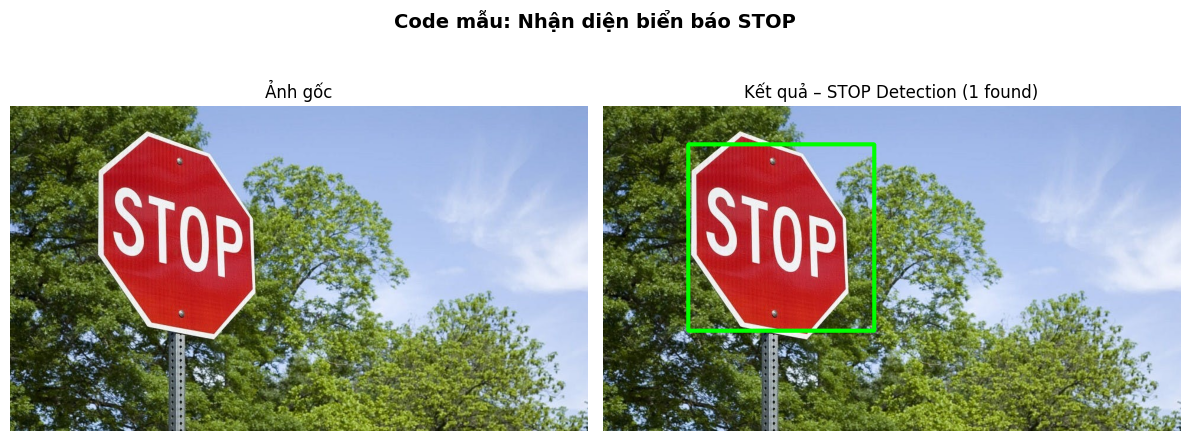

In [5]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load cascade classifier cho biển báo STOP
stop_data = cv2.CascadeClassifier('stop_data.xml')

# Phát hiện đối tượng
found = stop_data.detectMultiScale(img_gray, minSize=(20, 20))
amount_found = len(found)

img_result = img_rgb.copy()
if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_result, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
    print(f'Tìm thấy {amount_found} biển báo STOP!')
else:
    print('Không tìm thấy biển báo STOP.')

# Hiển thị kết quả
hnat.figure(figsize=(12, 5))
hnat.subplot(1, 2, 1)
hnat.imshow(img_rgb)
hnat.title('Ảnh gốc', fontsize=12)
hnat.axis('off')

hnat.subplot(1, 2, 2)
hnat.imshow(img_result)
hnat.title(f'Kết quả – STOP Detection ({amount_found} found)', fontsize=12)
hnat.axis('off')

hnat.suptitle('Code mẫu: Nhận diện biển báo STOP', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Đoạn code 2: Nhận diện khuôn mặt (Face Detection)

Tìm thấy 4 khuôn mặt!


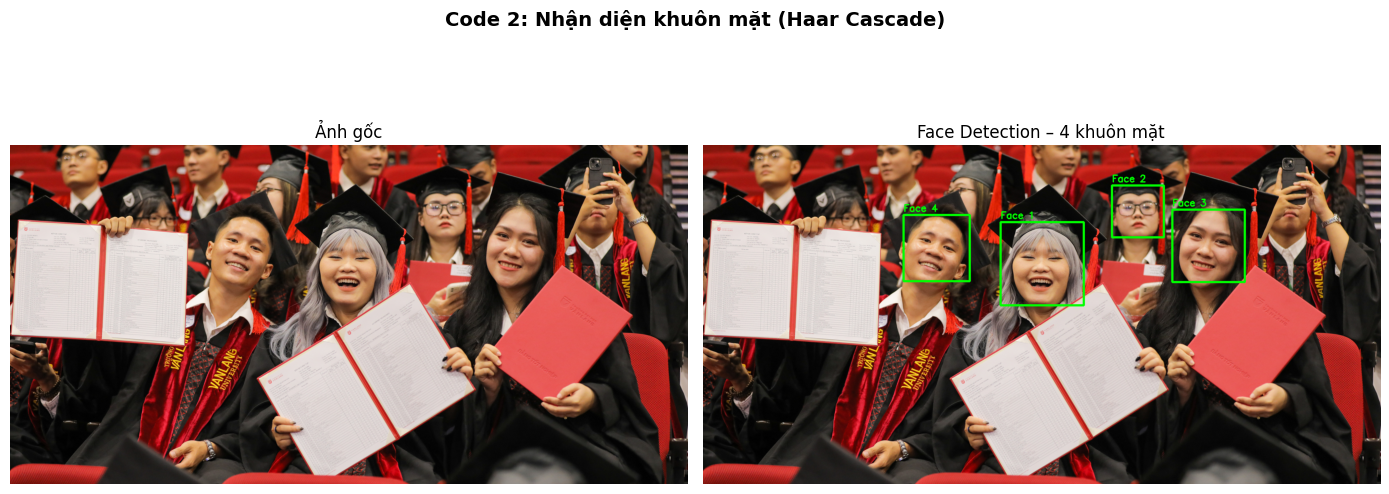

In [6]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img2_rgb  = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Load cascade classifier khuôn mặt
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Phát hiện khuôn mặt
# scaleFactor: tỉ lệ thu nhỏ ảnh mỗi bước (1.1 = 10%)
# minNeighbors: số hàng xóm tối thiểu để xác nhận detection
faces = face_cascade.detectMultiScale(
    img2_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

img2_face = img2_rgb.copy()
n_faces = len(faces)

for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(img2_face, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(img2_face, f'Face {i+1}', (x, y-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

print(f'Tìm thấy {n_faces} khuôn mặt!')

# Hiển thị kết quả
hnat.figure(figsize=(14, 6))
hnat.subplot(1, 2, 1)
hnat.imshow(img2_rgb)
hnat.title('Ảnh gốc', fontsize=12)
hnat.axis('off')

hnat.subplot(1, 2, 2)
hnat.imshow(img2_face)
hnat.title(f'Face Detection – {n_faces} khuôn mặt', fontsize=12)
hnat.axis('off')

hnat.suptitle('Code 2: Nhận diện khuôn mặt (Haar Cascade)', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Đoạn code 3: Nhận diện mắt và nụ cười

Khuôn mặt: 4 | Mắt: 7 | Nụ cười: 1


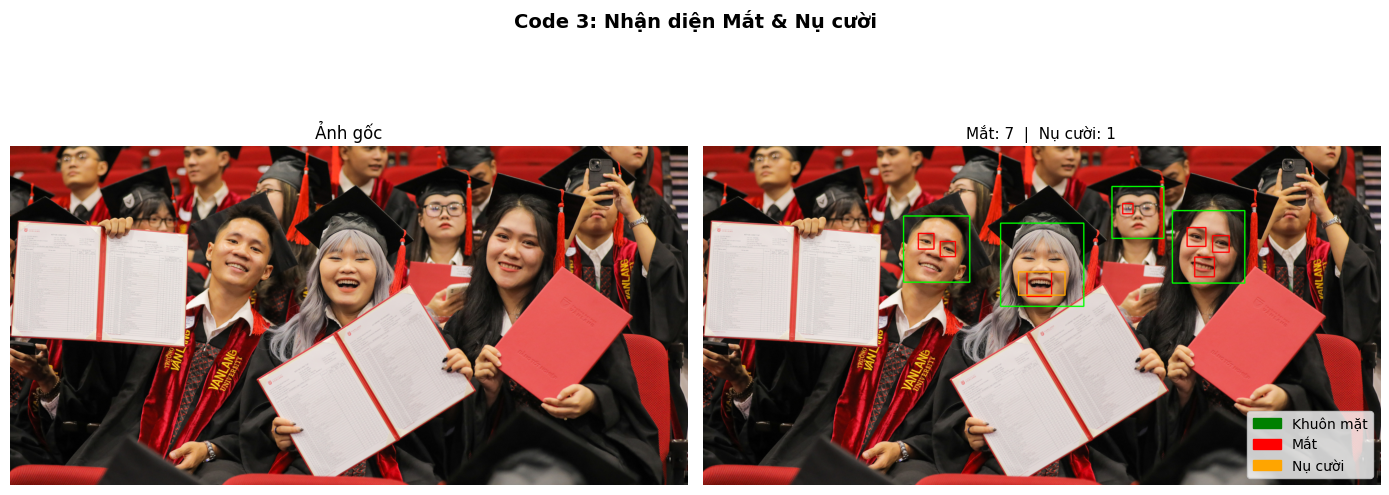

In [12]:
eye_cascade   = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

img3 = img2_rgb.copy()
n_eyes   = 0
n_smiles = 0

# Phát hiện khuôn mặt trước, rồi tìm mắt/nụ cười trong từng khuôn mặt
faces3 = face_cascade.detectMultiScale(
    img2_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
)

for (fx, fy, fw, fh) in faces3:
    # Vẽ khung khuôn mặt
    cv2.rectangle(img3, (fx, fy), (fx+fw, fy+fh), (0, 255, 0), 2)

    # Vùng ROI (Region of Interest) bên trong khuôn mặt
    roi_gray  = img2_gray[fy:fy+fh, fx:fx+fw]
    roi_color = img3[fy:fy+fh, fx:fx+fw]

    # Nhận diện mắt trong vùng khuôn mặt
    eyes = eye_cascade.detectMultiScale(
        roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15)
    )
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (255, 0, 0), 2)
        n_eyes += 1

    # Nhận diện nụ cười – tập trung nửa dưới khuôn mặt
    roi_gray_lower  = roi_gray[fh//2:, :]
    roi_color_lower = roi_color[fh//2:, :]
    smiles = smile_cascade.detectMultiScale(
        roi_gray_lower, scaleFactor=1.7, minNeighbors=22, minSize=(25, 25)
    )
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color_lower, (sx, sy), (sx+sw, sy+sh), (255, 165, 0), 2)
        n_smiles += 1

print(f'Khuôn mặt: {len(faces3)} | Mắt: {n_eyes} | Nụ cười: {n_smiles}')

# Hiển thị
hnat.figure(figsize=(14, 6))
hnat.subplot(1, 2, 1)
hnat.imshow(img2_rgb)
hnat.title('Ảnh gốc', fontsize=12)
hnat.axis('off')

hnat.subplot(1, 2, 2)
hnat.imshow(img3)
hnat.title(f'Mắt: {n_eyes}  |  Nụ cười: {n_smiles}', fontsize=11)
hnat.axis('off')

# Chú thích màu
from matplotlib.patches import Patch
legend = [
    Patch(color='green',  label='Khuôn mặt'),
    Patch(color='red',   label='Mắt'),
    Patch(color='orange', label='Nụ cười'),
]
hnat.legend(handles=legend, loc='lower right', fontsize=10)

hnat.suptitle('Code 3: Nhận diện Mắt & Nụ cười', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()

---
## Đoạn code 4: Nhận diện mũi và miệng

Khuôn mặt: 4 | Mũi: 3 | Miệng: 4


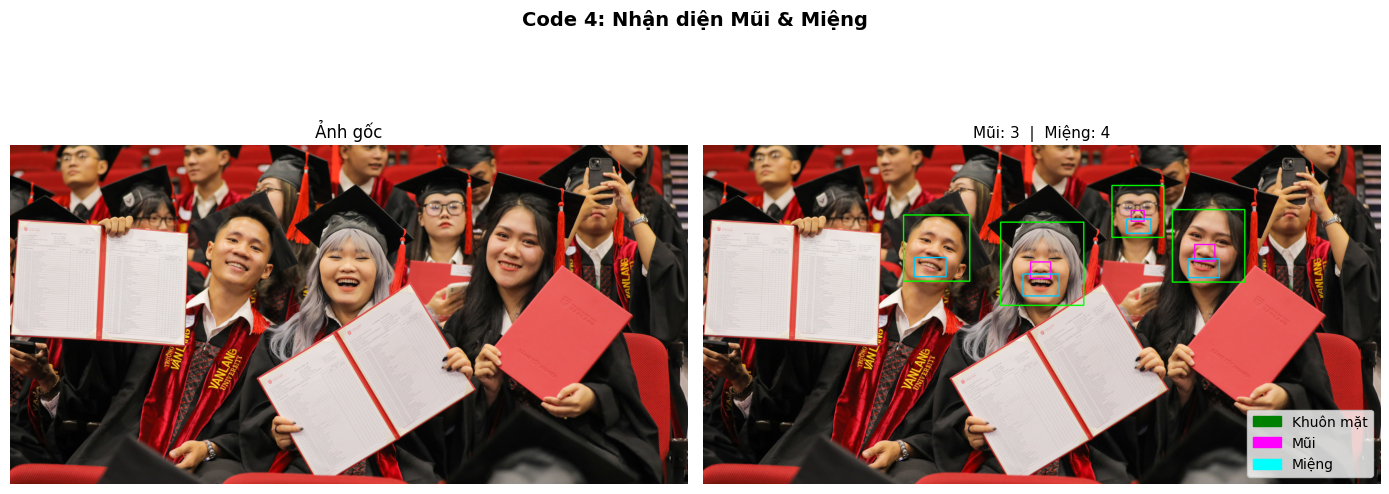

In [13]:
nose_cascade  = cv2.CascadeClassifier('haarcascade_mcs_nose.xml')
mouth_cascade = cv2.CascadeClassifier('haarcascade_mcs_mouth.xml')

img4 = img2_rgb.copy()
n_noses  = 0
n_mouths = 0

faces4 = face_cascade.detectMultiScale(
    img2_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
)

for (fx, fy, fw, fh) in faces4:
    cv2.rectangle(img4, (fx, fy), (fx+fw, fy+fh), (0, 255, 0), 2)
    roi_gray  = img2_gray[fy:fy+fh, fx:fx+fw]
    roi_color = img4[fy:fy+fh, fx:fx+fw]

    # Mũi – vùng giữa khuôn mặt
    roi_gray_mid  = roi_gray[fh//4 : 3*fh//4, :]
    roi_color_mid = roi_color[fh//4 : 3*fh//4, :]
    noses = nose_cascade.detectMultiScale(
        roi_gray_mid, scaleFactor=1.1, minNeighbors=8, minSize=(10, 10)
    )
    for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color_mid, (nx, ny), (nx+nw, ny+nh), (255, 0, 255), 2)
        n_noses += 1

    # Miệng – vùng nửa dưới khuôn mặt
    roi_gray_lower  = roi_gray[fh//2:, :]
    roi_color_lower = roi_color[fh//2:, :]
    mouths = mouth_cascade.detectMultiScale(
        roi_gray_lower, scaleFactor=1.1, minNeighbors=8, minSize=(20, 20)
    )
    for (mx, my, mw, mh) in mouths:
        cv2.rectangle(roi_color_lower, (mx, my), (mx+mw, my+mh), (0, 200, 255), 2)
        n_mouths += 1

print(f'Khuôn mặt: {len(faces4)} | Mũi: {n_noses} | Miệng: {n_mouths}')

hnat.figure(figsize=(14, 6))
hnat.subplot(1, 2, 1)
hnat.imshow(img2_rgb)
hnat.title('Ảnh gốc', fontsize=12)
hnat.axis('off')
hnat.subplot(1, 2, 2)
hnat.imshow(img4)
hnat.title(f'Mũi: {n_noses}  |  Miệng: {n_mouths}', fontsize=11)
hnat.axis('off')

from matplotlib.patches import Patch
legend4 = [
    Patch(color='green',   label='Khuôn mặt'),
    Patch(color='magenta', label='Mũi'),
    Patch(color='cyan',    label='Miệng'),
]
hnat.legend(handles=legend4, loc='lower right', fontsize=10)
hnat.suptitle('Code 4: Nhận diện Mũi & Miệng', fontsize=14, fontweight='bold')
hnat.tight_layout()
hnat.show()